In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
Data = pd.read_csv(r"C:\Users\singh\Downloads\archive (1)\data.csv")

# Understanding the data

In [3]:
Data.shape

(7691, 10)

In [4]:
Data.sample(5)

,house_type,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent
4423,3 BHK House for Rent in Manish Nagar Nagpur,Manish Nagar,Nagpur,1500,3,2.0,2,Semi-Furnished,15.0,23000
1577,"4 BHK Villa for Rent in Itpl, Whitefield Banga...",ITPL,Bangalore,3500,4,4.0,2,Furnished,40.0,140000
1266,"2 BHK Flat for Rent in Meena Apartments, IP Ex...",IP Extension,New Delhi,950,2,2.0,0,Unfurnished,32.0,30000
121,"3 BHK Flat for Rent in Mahendra Park, Jhangir ...",Mahendra Park,New Delhi,200,3,2.0,2,Unfurnished,130.0,26000
594,4 BHK Villa for Rent in Sir M Visvesvaraya Ins...,Sir M Visvesvaraya Inst Road,Bangalore,3310,4,4.0,3,Semi-Furnished,57.0,190000


In [5]:
Data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7691 entries, 0 to 7690
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   house_type  7691 non-null   object 
 1   locality    7691 non-null   object 
 2   city        7691 non-null   object 
 3   area        7691 non-null   int64  
 4   beds        7691 non-null   int64  
 5   bathrooms   7689 non-null   float64
 6   balconies   7691 non-null   int64  
 7   furnishing  7688 non-null   object 
 8   area_rate   7691 non-null   float64
 9   rent        7691 non-null   int64  
dtypes: float64(2), int64(4), object(4)
memory usage: 601.0+ KB


In [6]:
Data.isnull().sum()

house_type    0
locality      0
city          0
area          0
beds          0
bathrooms     2
balconies     0
furnishing    3
area_rate     0
rent          0
dtype: int64

In [7]:
Data.duplicated().sum()

np.int64(0)

In [8]:
cat_col =Data.select_dtypes(include= "object").columns
num_col =Data.select_dtypes(include= ["int64","float64"]).columns 
num_col,cat_col

(Index(['area', 'beds', 'bathrooms', 'balconies', 'area_rate', 'rent'], dtype='object'),
 Index(['house_type', 'locality', 'city', 'furnishing'], dtype='object'))

In [9]:
# Data = Data.dropna(subset=["bathrooms","furnishing"])

# Handleing missing values

In [10]:
# mean,mediam--> numerical col
# mode--> categorical column

In [11]:
median_col = Data['bathrooms'].median()
median_col

2.0

In [12]:
Data['bathrooms'] = Data['bathrooms'].fillna(median_col)

In [13]:
mode_val = Data['furnishing'].mode()[0]
mode_val

'Semi-Furnished'

In [14]:
Data['furnishing'] = Data['furnishing'].fillna(mode_val)

In [15]:
for col in cat_col:
    print(f"Unique categories in {col} are:")
    print(Data[col].value_counts())
    print("="*80+'\n')

# if categories are equal to the number of rows simply drop that column

Unique categories in house_type are:
house_type
3 BHK Flat for Rent in Whitefield, Bangalore                              28
3 BHK Flat for Rent in Sarjapur Road, Bangalore                           24
3 BHK Flat for Rent in Hebbal, Bangalore                                  24
3 BHK Flat for Rent in Oberoi Sky City, Borivali East, Mumbai             20
1 BHK Flat for Rent in Hadapsar, Pune                                     19
                                                                          ..
2 BHK Flat for Rent in Jakkuru Main Road, Bangalore                        1
2 BHK House for Rent in Krishna Nagar New Delhi                            1
2 BHK Flat for Rent in Sone Gaon, Nagpur                                   1
2 BHK Flat for Rent in Lake View Apartment, Sector 9 Rohini, New Delhi     1
2 BHK Flat for Rent in Govindpura, Dooravani Nagar, Bangalore              1
Name: count, Length: 5467, dtype: int64

Unique categories in locality are:
locality
Hadapsar            

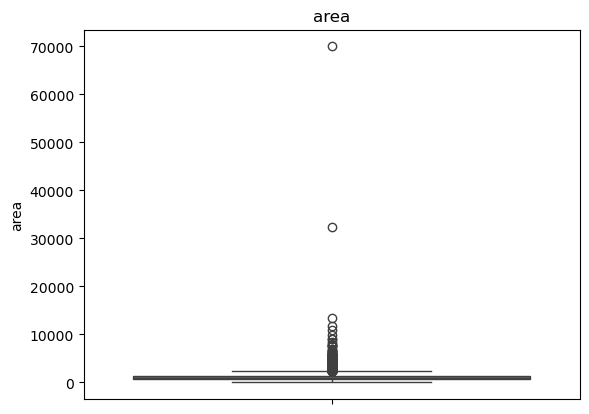

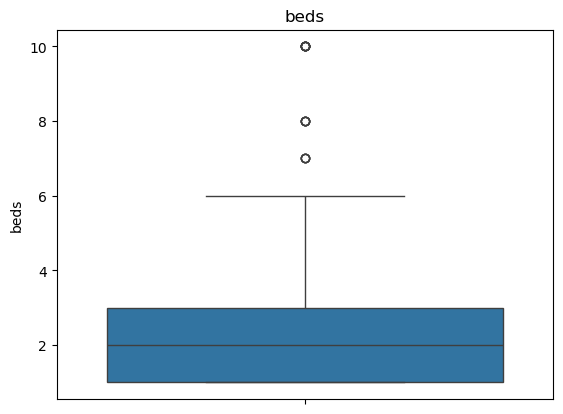

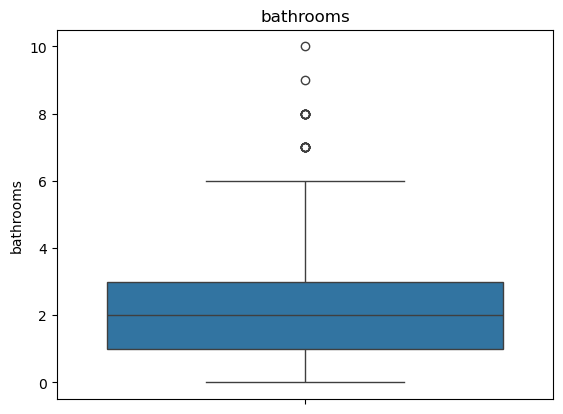

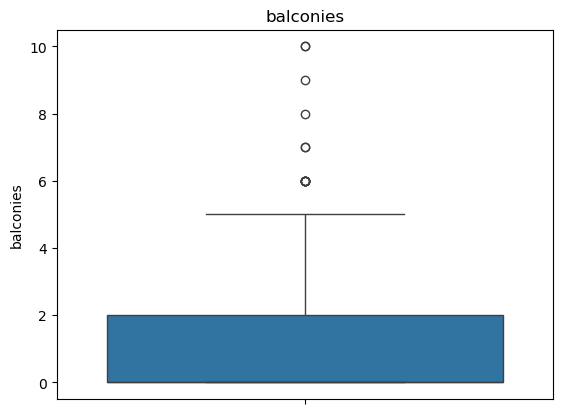

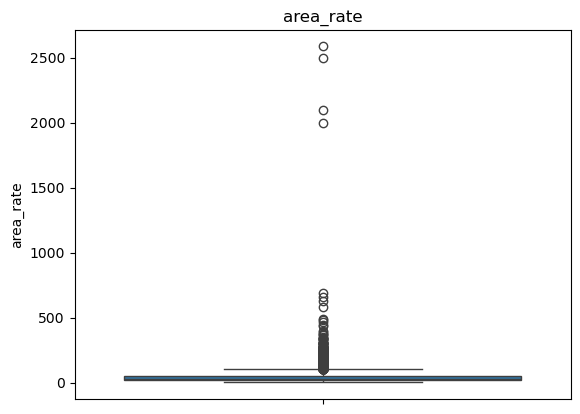

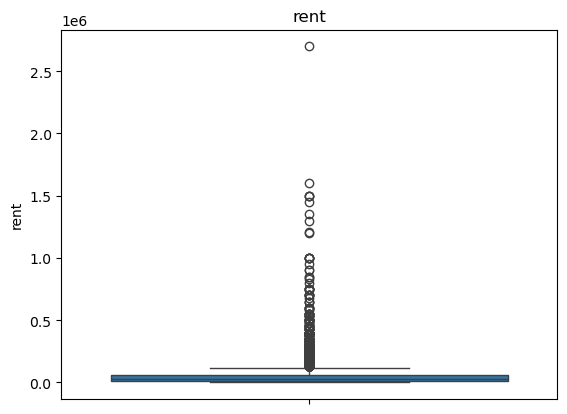

In [16]:
for col in num_col:
    sns.boxplot(Data[col])
    plt.title(col)
    plt.show()

In [17]:
# In Excel when we ploted Box plot, min and max values are basically min and max value of dataset set itself
# In seaborn min and max are calculated on the basis of IQR
# IQR = Q3-Q1
# min_whisker = q1-(1.5*IQR)
# max_whisker = q3+(1.5*IQR)

q1 = Data["bathrooms"].quantile(0.25)
q2=Data["bathrooms"].quantile(0.5)
q3 = Data["bathrooms"].quantile(0.75)
IQR = q3-q1
ll = q1-(1.5*IQR)
ul = q3+(1.5*IQR)
ll,q1,q2,q3,ul

(np.float64(-2.0),
 np.float64(1.0),
 np.float64(2.0),
 np.float64(3.0),
 np.float64(6.0))

In [18]:
select_rows = Data[(Data['bathrooms']<ll) | (Data['bathrooms']>ul)]
(select_rows.shape[0]/Data.shape[0])*100

0.24704199713951372

In [19]:
def get_ll_ul(Data,col):
    q1 = Data[col].quantile(0.25)
    q3 = Data[col].quantile(0.75)
    IQR = q3-q1
    ll = q1-(1.5*IQR)
    ul = q3+(1.5*IQR)
    return ll,ul     

In [20]:
for col in num_col:
    ll,ul = get_ll_ul(Data,col)
    select_rows = Data[(Data[col]<ll) | (Data[col]>ul)].shape[0]
    print(col,"-->",select_rows," ",(select_rows/Data.shape[0])*100)

area --> 490   6.371083084124302
beds --> 17   0.22103757638798596
bathrooms --> 19   0.24704199713951372
balconies --> 13   0.16902873488493045
area_rate --> 666   8.659472110258744
rent --> 713   9.270575997919646


In [21]:
Outlier_col = ['beds','balconies','bathrooms']
for col in Outlier_col:
    ll,ul = get_ll_ul(Data,col)
    Data = Data[(Data[col]>=ll) & (Data[col]<=ul)]
    Data.reset_index(drop = True, inplace= True)
    print(f"Outlier Removed from {col}")

Outlier Removed from beds
Outlier Removed from balconies
Outlier Removed from bathrooms


In [22]:
# Feature Engineering
Data[['house_type','beds']].sample(10)

,house_type,beds
3088,"2 BHK Flat for Rent in Aya Nagar, New Delhi",2
2167,"3 BHK Flat for Rent in Mantra Essence, Undri, ...",3
4662,"2 BHK Flat for Rent in Mantra Essence, Wadachi...",2
5275,3 BHK Flat for Rent in Sarjapura Attibele Road...,3
4643,"2 BHK Flat for Rent in Laxmi Nagar, Nagpur",2
7556,3 BHK Villa for Rent in Wadgaon Sheri Pune,3
556,"3 BHK Flat for Rent in Oberoi Sky City, Boriva...",3
4385,3 BHK Flat for Rent in MICL Aaradhya High Park...,3
769,"2 BHK Flat for Rent in Kalkaji, New Delhi",2
2165,2 BHK Flat for Rent in Murkute Ascent Building...,2


In [23]:
Data['property_type'] = Data['house_type'].apply(lambda x: (x.split()[2]))
Data['property_type'].value_counts()

property_type
Flat     5878
House    1547
Villa     229
Name: count, dtype: int64

In [26]:
Data.columns

Index(['locality', 'city', 'area', 'beds', 'bathrooms', 'balconies',
       'furnishing', 'area_rate', 'rent', 'property_type'],
      dtype='object')

In [25]:
Data.drop(columns = ['house_type'],axis=1, inplace = True)

In [29]:
Data.sample(5)

,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent,property_type
6754,1915,3,1200,1,1.0,2,2,8.0,10000,0
6240,1778,1,1277,2,3.0,0,2,70.0,90000,0
1953,855,3,580,2,2.0,0,0,53.0,31000,0
565,279,3,300,1,1.0,0,2,50.0,15000,1
1780,658,0,1150,2,2.0,2,1,52.0,60000,0


In [28]:
# Converting categorical col to numerical(Encoding)

from sklearn.preprocessing import LabelEncoder
categorical_col=["locality","city","furnishing","property_type"]

for col in categorical_col:
    le = LabelEncoder()
    Data[col] = le.fit_transform(Data[col])